## imports

In [1]:
import os
import copy
import math
import yaml
import json
import logging
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field, asdict
import dataclasses

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from ultralytics import YOLO

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device : {DEVICE}")
print(f"pytorch : {torch.__version__}")


device : cpu
pytorch : 2.11.0+cu130


/home/tombellivier/Documents/CV/CV-for-GRIT/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## config

In [2]:
@dataclass
class LoRAConfig:
    """hyperparamètres lora."""
    rank: int = 8
    alpha: float = 16.0
    dropout: float = 0.05
    target_modules: List[str] = field(
        default_factory=lambda: ["Conv2d", "Linear"]
    )
    min_weight_size: int = 16


@dataclass
class TrainingConfig:
    """hyperparamètres d'entraînement."""
    epochs: int = 30
    batch_size: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-2
    warmup_epochs: int = 3
    grad_clip: float = 1.0
    save_dir: str = "./checkpoints"
    img_size: int = 640


@dataclass
class InsectConfig:
    """configuration des groupes d'insectes."""
    groups: Dict[str, str] = field(default_factory=lambda: {
        "lepidoptera": "../datasets/Lepidoptera",
        "hymenoptera": "../datasets/Hymenoptera",
        "coleoptera": "../datasets/Coleoptera"
    })
    num_keypoints: int = 42
    base_model: str = "config.yaml"


lora_cfg = LoRAConfig()
train_cfg = TrainingConfig()
insect_cfg = InsectConfig()

print("configuration lora :")
print(json.dumps(asdict(lora_cfg), indent=2))
print("\ngroupes d'insectes :")
for grp in insect_cfg.groups:
    print(f"  • {grp}")


configuration lora :
{
  "rank": 8,
  "alpha": 16.0,
  "dropout": 0.05,
  "target_modules": [
    "Conv2d",
    "Linear"
  ],
  "min_weight_size": 16
}

groupes d'insectes :
  • lepidoptera
  • hymenoptera
  • coleoptera


## LoRA

Pour une couche de poids $W_0 \in \mathbb{R}^{d_{out} \times d_{in}}$, on remplace la mise à jour par :

$$h = W_0 x + \underbrace{\frac{\alpha}{r} \cdot BA}_{\Delta W} x$$

avec $A \in \mathbb{R}^{r \times d_{in}}$, $B \in \mathbb{R}^{d_{out} \times r}$, $r \ll \min(d_{in}, d_{out})$.

In [3]:
class LoRALinear(nn.Module):
    """adaptateur lora pour nn.Linear (W_base gelé, seuls A et B entraînés)."""

    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int,
        alpha: float,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.base_layer = base_layer
        for p in self.base_layer.parameters():
            p.requires_grad = False

        in_features  = base_layer.in_features
        out_features = base_layer.out_features
        self.rank    = rank
        self.scaling = alpha / rank

        self.lora_A  = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B  = nn.Parameter(torch.zeros(out_features, rank))
        self.dropout = nn.Dropout(dropout)

        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base_layer(x)
        lora_out = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        return base_out + self.scaling * lora_out

    def extra_repr(self) -> str:
        return (f"rank={self.rank}, scaling={self.scaling:.3f}, "
                f"in={self.base_layer.in_features}, out={self.base_layer.out_features}")


class LoRAConv2d(nn.Module):
    """adaptateur lora pour nn.Conv2d via deux convolutions séquentielles de rang réduit."""

    def __init__(
        self,
        base_layer: nn.Conv2d,
        rank: int,
        alpha: float,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.base_layer = base_layer
        for p in self.base_layer.parameters():
            p.requires_grad = False

        in_ch  = base_layer.in_channels
        out_ch = base_layer.out_channels
        k      = base_layer.kernel_size
        pad    = base_layer.padding
        stride = base_layer.stride

        self.rank    = rank
        self.scaling = alpha / rank

        self.lora_down = nn.Conv2d(in_ch, rank, 1, bias=False)
        self.lora_up   = nn.Conv2d(rank, out_ch, k,
                                   padding=pad, stride=stride, bias=False)
        self.dropout   = nn.Dropout2d(dropout)

        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.base_layer(x) + self.scaling * self.lora_up(self.lora_down(self.dropout(x)))

    def extra_repr(self) -> str:
        return (f"rank={self.rank}, scaling={self.scaling:.3f}, "
                f"in_ch={self.base_layer.in_channels}, out_ch={self.base_layer.out_channels}")


print("✓ LoRALinear et LoRAConv2d définis")


✓ LoRALinear et LoRAConv2d définis


### 2.2 Injection des adaptateurs dans le modèle

In [4]:
class LoRAInjector:
    """remplace récursivement les couches cibles par leurs équivalents lora."""

    def __init__(self, config: LoRAConfig):
        self.config   = config
        self._injected: List[str] = []
        self._skipped:  List[str] = []

    def inject(self, model: nn.Module) -> nn.Module:
        """injecte lora dans model (in-place) et retourne le modèle."""
        self._replace_recursive(model, prefix="")
        logger.info(
            f"lora injecté dans {len(self._injected)} couches, "
            f"{len(self._skipped)} ignorées (trop petites)."
        )
        return model

    def _should_replace(self, module: nn.Module, name: str) -> bool:
        module_type = type(module).__name__
        if module_type not in self.config.target_modules:
            return False
        if isinstance(module, nn.Linear):
            return min(module.in_features, module.out_features) >= self.config.min_weight_size
        if isinstance(module, nn.Conv2d):
            return min(module.in_channels, module.out_channels) >= self.config.min_weight_size
        return False

    def _replace_recursive(self, module: nn.Module, prefix: str):
        for child_name, child_module in list(module.named_children()):
            full_name = f"{prefix}.{child_name}" if prefix else child_name
            if self._should_replace(child_module, full_name):
                setattr(module, child_name, self._wrap(child_module))
                self._injected.append(full_name)
            else:
                self._replace_recursive(child_module, full_name)

    def _wrap(self, module: nn.Module) -> nn.Module:
        cfg = self.config
        if isinstance(module, nn.Linear):
            return LoRALinear(module, cfg.rank, cfg.alpha, cfg.dropout)
        if isinstance(module, nn.Conv2d):
            return LoRAConv2d(module, cfg.rank, cfg.alpha, cfg.dropout)
        raise TypeError(f"type non supporté : {type(module)}")

    @property
    def injected_layers(self) -> List[str]:
        return self._injected


def freeze_base_model(model: nn.Module) -> int:
    """gèle tous les paramètres sauf les adaptateurs lora."""
    frozen = 0
    for name, param in model.named_parameters():
        if any(k in name for k in ("lora_A", "lora_B", "lora_down", "lora_up")):
            param.requires_grad = True
        else:
            param.requires_grad = False
            frozen += param.numel()
    return frozen


def count_parameters(model: nn.Module) -> Dict[str, int]:
    """retourne total / trainable / frozen."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable, "frozen": total - trainable}


print("✓ LoRAInjector défini")


✓ LoRAInjector défini


### 2.3 Gestionnaire des poids LoRA par groupe

In [5]:
class LoRAWeightManager:
    """
    sauvegarde, charge et échange les poids lora par groupe d'insectes.
    seuls lora_A / lora_B / lora_down / lora_up sont stockés → stockage minimal.
    """

    LORA_KEYS = ("lora_A", "lora_B", "lora_down.weight", "lora_up.weight")

    def __init__(self, save_dir: str):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self._cache: Dict[str, Dict[str, torch.Tensor]] = {}

    @staticmethod
    def extract_lora_state(model: nn.Module) -> Dict[str, torch.Tensor]:
        """extrait uniquement les paramètres lora du state_dict."""
        return {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
            if any(key in k for key in LoRAWeightManager.LORA_KEYS)
        }

    @staticmethod
    def apply_lora_state(model: nn.Module, lora_state: Dict[str, torch.Tensor]):
        """charge des poids lora dans le modèle sans modifier les poids de base."""
        current_state = model.state_dict()
        current_state.update(lora_state)
        model.load_state_dict(current_state, strict=False)

    def save_group(self, group_name: str, model: nn.Module, metadata: Optional[dict] = None):
        """sauvegarde les poids lora d'un groupe sur disque."""
        lora_state = self.extract_lora_state(model)
        checkpoint = {
            "group": group_name,
            "lora_state": lora_state,
            "metadata": metadata or {},
            "param_count": sum(v.numel() for v in lora_state.values()),
        }
        path = self.save_dir / f"lora_{group_name}.pt"
        torch.save(checkpoint, path)
        self._cache[group_name] = lora_state
        logger.info(f"  → groupe '{group_name}' sauvegardé : {path} "
                    f"({checkpoint['param_count']:,} params lora)")
        return path

    def load_group(self, group_name: str, model: nn.Module) -> dict:
        """charge et applique les poids lora d'un groupe."""
        if group_name in self._cache:
            self.apply_lora_state(model, self._cache[group_name])
            return {"source": "cache"}

        path = self.save_dir / f"lora_{group_name}.pt"
        if not path.exists():
            raise FileNotFoundError(f"pas de checkpoint pour le groupe '{group_name}' : {path}")
        checkpoint = torch.load(path, map_location=DEVICE)
        self.apply_lora_state(model, checkpoint["lora_state"])
        self._cache[group_name] = checkpoint["lora_state"]
        logger.info(f"  ← groupe '{group_name}' chargé depuis {path}")
        return checkpoint.get("metadata", {})

    def summary(self):
        """affiche un tableau des groupes disponibles sur disque."""
        files = list(self.save_dir.glob("lora_*.pt"))
        if not files:
            print("aucun groupe sauvegardé.")
            return
        print(f"{'Groupe':<20} {'Paramètres LoRA':>18} {'Taille (Mo)':>12}")
        print("-" * 55)
        for f in sorted(files):
            ck = torch.load(f, map_location="cpu")
            size_mb = f.stat().st_size / 1e6
            print(f"{ck['group']:<20} {ck['param_count']:>18,} {size_mb:>12.3f}")


lora_manager = LoRAWeightManager(train_cfg.save_dir)
print("✓ LoRAWeightManager instancié")


✓ LoRAWeightManager instancié


## 3. Modèle YOLO-Pose + LoRA

In [6]:
class YOLOPoseLoRA(nn.Module):
    """
    encapsule un modèle yolo-pose avec adaptateurs lora injectés.

    utilisation :
        model = YOLOPoseLoRA("yolov8n-pose.pt", lora_cfg)
        model.switch_group("coleoptera", lora_manager)
        preds = model(images)
    """

    def __init__(
        self,
        base_model_path: str,
        lora_config: LoRAConfig,
    ):
        super().__init__()
        yolo = self.load_yolo(base_model_path)
        
        self.backbone: nn.Module = yolo.model
        self.backbone.eval()

        injector = LoRAInjector(lora_config)
        injector.inject(self.backbone)
        freeze_base_model(self.backbone)

        stats = count_parameters(self.backbone)
        self._lora_config  = lora_config
        self._active_group: Optional[str] = None

        logger.info("YOLOPoseLoRA initialisé :")
        logger.info(f"  • paramètres totaux   : {stats['total']:>12,}")
        logger.info(f"  • paramètres gelés    : {stats['frozen']:>12,}")
        logger.info(f"  • paramètres lora     : {stats['trainable']:>12,}  "
                    f"({100*stats['trainable']/stats['total']:.2f}% du total)")
        logger.info(f"  • couches lora        : {len(injector.injected_layers)}")
    
    def load_yolo(self, base_model_path: str):

        # Ou avec transfert partiel des poids backbone
        yolo = YOLO(base_model_path)
        yolo_pretrained = YOLO("yolo26n-pose.pt")

        # Transférer uniquement le backbone (pas la tête)
        pretrained_state = yolo_pretrained.model.state_dict()
        current_state    = yolo.model.state_dict()

        transferred = {
            k: v for k, v in pretrained_state.items()
            if k in current_state and v.shape == current_state[k].shape
        }
        current_state.update(transferred)
        yolo.model.load_state_dict(current_state)

        n_transferred = len(transferred)
        n_total       = len(current_state)
        print(f"Poids transférés : {n_transferred}/{n_total} couches")

        return yolo


    def forward(self, x: torch.Tensor):
        return self.backbone(x)

    def switch_group(self, group_name: str, manager: LoRAWeightManager):
        """charge les poids lora du groupe spécifié."""
        manager.load_group(group_name, self.backbone)
        self._active_group = group_name
        logger.info(f"groupe actif → '{group_name}'")

    def save_current_group(self, manager: LoRAWeightManager, metadata: Optional[dict] = None):
        if self._active_group is None:
            raise ValueError("aucun groupe actif à sauvegarder.")
        return manager.save_group(self._active_group, self.backbone, metadata)

    def get_lora_params(self) -> List[nn.Parameter]:
        """retourne uniquement les paramètres lora pour l'optimiseur."""
        return [p for p in self.backbone.parameters() if p.requires_grad]

    @property
    def active_group(self) -> Optional[str]:
        return self._active_group


print("✓ classe YOLOPoseLoRA définie")


✓ classe YOLOPoseLoRA définie


### 3.1 Instanciation du modèle de base

WARNING ⚠️ no model scale passed. Assuming scale='n'.


2026-05-28 08:46:31,983 - INFO - lora injecté dans 147 couches, 0 ignorées (trop petites).
2026-05-28 08:46:31,986 - INFO - YOLOPoseLoRA initialisé :
2026-05-28 08:46:31,986 - INFO -   • paramètres totaux   :    7,532,002
2026-05-28 08:46:31,986 - INFO -   • paramètres gelés    :    6,903,714
2026-05-28 08:46:31,986 - INFO -   • paramètres lora     :      628,288  (8.34% du total)
2026-05-28 08:46:31,987 - INFO -   • couches lora        : 147


Poids transférés : 795/879 couches


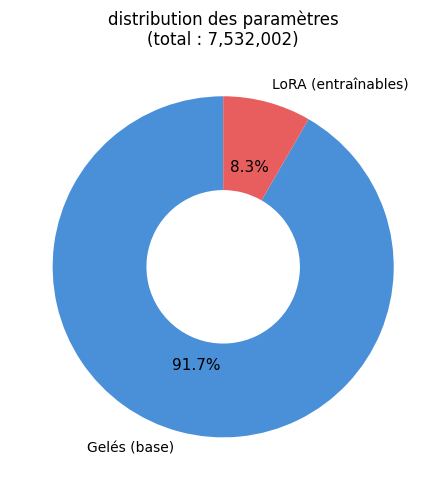


réduction : seuls 628,288 paramètres entraînés par groupe.


In [7]:
model = YOLOPoseLoRA(
    base_model_path = insect_cfg.base_model,
    lora_config     = lora_cfg,
).to(DEVICE)

stats  = count_parameters(model.backbone)
labels = ["Gelés (base)", "LoRA (entraînables)"]
sizes  = [stats["frozen"], stats["trainable"]]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%",
    colors=["#4A90D9", "#E85D5D"],
    startangle=90, wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title(f"distribution des paramètres\n(total : {stats['total']:,})", fontsize=12)
plt.tight_layout()
plt.show()
print(f"\nréduction : seuls {stats['trainable']:,} paramètres entraînés par groupe.")


## 4. Dataset — Format YOLO Pose

Format attendu : dossiers `images/` et `labels/` au format YOLO.
Chaque ligne de label :
```
class cx cy w h  kp1x kp1y kp1v  kp2x kp2y kp2v ...
```
(coordonnées normalisées, visibilité 0/1/2)

In [8]:
import cv2
from torchvision import transforms as T


class InsectPoseDataset(Dataset):
    """
    dataset yolo-format pour la pose estimation d'insectes.

    structure attendue :
        data/<group>/images/train|val/
        data/<group>/labels/train|val/
    """

    def __init__(
        self,
        root_dir: str,
        split: str = "train",
        img_size: int = 640,
        num_keypoints: int = 42,
        augment: bool = True,
    ):
        self.root      = Path(root_dir)
        self.img_size  = img_size
        self.num_kp    = num_keypoints
        self.augment   = augment and split == "train"
        self.img_dir   = self.root / "images" / split
        self.lbl_dir   = self.root / "labels" / split
        self.samples   = self._scan_samples()
        self.transform = self._build_transform()
        logger.info(f"dataset [{split}] : {len(self.samples)} images — {self.root.name}")

    def _scan_samples(self) -> List[Path]:
        exts = (".jpg", ".jpeg", ".png", ".bmp")
        imgs = sorted([p for p in self.img_dir.glob("*") if p.suffix.lower() in exts])
        return [p for p in imgs if (self.lbl_dir / p.with_suffix(".txt").name).exists()]

    def _build_transform(self) -> T.Compose:
        normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        if self.augment:
            return T.Compose([
                T.ToPILImage(),
                T.ColorJitter(0.3, 0.3, 0.2, 0.05),
                T.RandomHorizontalFlip(0.3),
                T.ToTensor(),
                normalize,
            ])
        return T.Compose([T.ToPILImage(), T.ToTensor(), normalize])

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path = self.samples[idx]
        lbl_path = self.lbl_dir / img_path.with_suffix(".txt").name

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img_tensor = self.transform(img)

        targets = []
        with open(lbl_path) as f:
            for line in f:
                vals = list(map(float, line.strip().split()))
                if len(vals) >= 5 + 3 * self.num_kp:
                    targets.append(vals)

        targets_tensor = torch.zeros(len(targets), 5 + 3 * self.num_kp)
        for i, t in enumerate(targets):
            targets_tensor[i] = torch.tensor(t[:5 + 3 * self.num_kp])

        return img_tensor, targets_tensor, str(img_path)


def build_dataloaders(
    group_name: str,
    data_dir: str,
    cfg: TrainingConfig,
    insect_cfg_: InsectConfig,
) -> Tuple[DataLoader, DataLoader]:
    """crée les dataloaders train/val pour un groupe d'insectes."""

    def collate(batch):
        imgs, labels, paths = zip(*batch)
        return torch.stack(imgs), labels, paths

    train_ds = InsectPoseDataset(data_dir, "train", cfg.img_size, insect_cfg_.num_keypoints)
    val_ds   = InsectPoseDataset(data_dir, "val",   cfg.img_size, insect_cfg_.num_keypoints, augment=False)

    train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, collate_fn=collate)
    val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate)

    return train_dl, val_dl


print("✓ InsectPoseDataset et build_dataloaders définis")


✓ InsectPoseDataset et build_dataloaders définis


## 5. Fonctions de loss

Combinaison :
- **L_bbox** : CIoU loss (boîtes englobantes)
- **L_kp** : MSE pondéré par la visibilité des keypoints
- **L_reg** : régularisation L2 sur les poids LoRA

In [9]:
def keypoint_loss(
    pred_kps: torch.Tensor,
    gt_kps:   torch.Tensor,
    visibility: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """mse sur les keypoints pondéré par la visibilité. pred/gt : [B, N, 2]."""
    loss = F.mse_loss(pred_kps, gt_kps, reduction="none").sum(-1)  # [B, N]
    if visibility is not None:
        loss  = loss * (visibility > 0).float()
        denom = (visibility > 0).float().sum().clamp(min=1)
        return loss.sum() / denom
    return loss.mean()


def bbox_ciou_loss(
    pred_boxes: torch.Tensor,
    gt_boxes:   torch.Tensor,
    eps: float = 1e-7,
) -> torch.Tensor:
    """ciou loss pour boîtes au format [cx, cy, w, h] normalisé."""

    def xywh2xyxy(b):
        return torch.stack([
            b[..., 0] - b[..., 2] / 2,
            b[..., 1] - b[..., 3] / 2,
            b[..., 0] + b[..., 2] / 2,
            b[..., 1] + b[..., 3] / 2,
        ], dim=-1)

    pb = xywh2xyxy(pred_boxes)
    gb = xywh2xyxy(gt_boxes)

    inter_x1 = torch.max(pb[..., 0], gb[..., 0])
    inter_y1 = torch.max(pb[..., 1], gb[..., 1])
    inter_x2 = torch.min(pb[..., 2], gb[..., 2])
    inter_y2 = torch.min(pb[..., 3], gb[..., 3])
    inter    = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)

    area_p = (pb[..., 2] - pb[..., 0]) * (pb[..., 3] - pb[..., 1])
    area_g = (gb[..., 2] - gb[..., 0]) * (gb[..., 3] - gb[..., 1])
    union  = area_p + area_g - inter + eps
    iou    = inter / union

    enc_x1 = torch.min(pb[..., 0], gb[..., 0])
    enc_y1 = torch.min(pb[..., 1], gb[..., 1])
    enc_x2 = torch.max(pb[..., 2], gb[..., 2])
    enc_y2 = torch.max(pb[..., 3], gb[..., 3])
    c2     = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + eps

    rho2 = ((pred_boxes[..., 0] - gt_boxes[..., 0]) ** 2 +
            (pred_boxes[..., 1] - gt_boxes[..., 1]) ** 2)

    with torch.no_grad():
        v = (4 / math.pi ** 2) * (
            torch.atan(gt_boxes[..., 2] / (gt_boxes[..., 3] + eps)) -
            torch.atan(pred_boxes[..., 2] / (pred_boxes[..., 3] + eps))
        ) ** 2
        alpha_c = v / (1 - iou + v + eps)

    ciou = iou - (rho2 / c2) - alpha_c * v
    return (1 - ciou).mean()


def lora_regularization(model: nn.Module, lambda_reg: float = 1e-4) -> torch.Tensor:
    """régularisation l2 légère sur les matrices lora entraînables."""
    reg = torch.tensor(0.0, device=DEVICE)
    for name, param in model.named_parameters():
        if param.requires_grad:
            reg = reg + param.norm(2) ** 2
    return lambda_reg * reg


print("✓ fonctions de loss définies")


✓ fonctions de loss définies


## 6. Boucle d'entraînement LoRA

In [10]:
from ultralytics.utils import IterableSimpleNamespace
from ultralytics.utils.loss import PoseLoss26


class LoRATrainer:
    """
    entraîne les adaptateurs lora pour un groupe d'insectes.
    le backbone yolo est gelé ; seuls les poids a et b sont mis à jour.
    """

    def __init__(
        self,
        model: YOLOPoseLoRA,
        manager: LoRAWeightManager,
        config: TrainingConfig,
    ):
        self.model   = model
        self.manager = manager
        self.cfg     = config
        self.history: Dict[str, Dict[str, List[float]]] = {}

    def _build_optimizer(self):
        return AdamW(self.model.get_lora_params(),
                     lr=self.cfg.lr, weight_decay=self.cfg.weight_decay)

    def _warmup_lr(self, optimizer, epoch: int):
        if epoch < self.cfg.warmup_epochs:
            factor = (epoch + 1) / self.cfg.warmup_epochs
            for pg in optimizer.param_groups:
                pg["lr"] = self.cfg.lr * factor

    def _train_epoch(self, loader: DataLoader, optimizer, epoch: int) -> float:
        self.model.backbone.train()
        # maintenir bn en mode eval (poids gelés)
        for m in self.model.backbone.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                m.eval()

        total_loss = 0.0
        for imgs, targets_list, _ in loader:
            imgs = imgs.to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                preds = self.model(imgs)
                loss  = self._compute_loss(preds, targets_list)
                loss  = loss + lora_regularization(self.model.backbone)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.get_lora_params(), self.cfg.grad_clip)
            optimizer.step()
            total_loss += loss.item()

        return total_loss / max(len(loader), 1)

    @torch.no_grad()
    def _val_epoch(self, loader: DataLoader) -> float:
        self.model.backbone.eval()
        total_loss = 0.0
        for imgs, targets_list, _ in loader:
            imgs  = imgs.to(DEVICE)
            preds = self.model(imgs)
            loss  = self._compute_loss(preds, targets_list)
            total_loss += loss.item()
        return total_loss / max(len(loader), 1)

    def _compute_loss(self, preds, targets_list) -> torch.Tensor:
        """assemble le batch et appelle la loss interne du head yolo."""

        batch_idx, classes, bboxes, keypoints = [], [], [], []
        num_kp = insect_cfg.num_keypoints

        for i, t in enumerate(targets_list):
            if t.shape[0] == 0:
                continue
            t = t.to(DEVICE)
            n = t.shape[0]
            batch_idx.append(torch.full((n,), i, dtype=torch.float32, device=DEVICE))
            classes.append(t[:, 0])
            bboxes.append(t[:, 1:5])
            keypoints.append(t[:, 5:5 + 3 * num_kp].view(n, num_kp, 3))

        if not batch_idx:
            return torch.tensor(0.0, device=DEVICE, requires_grad=True)

        batch = {
            "batch_idx": torch.cat(batch_idx),
            "cls":       torch.cat(classes),
            "bboxes":    torch.cat(bboxes),
            "keypoints": torch.cat(keypoints),
            "img":       torch.zeros(len(targets_list), device=DEVICE),
        }

        self.model.backbone.args = {}  # If args doesn't exist yet
        self.model.backbone.args["box"] = 7.5
        self.model.backbone.args["cls"] = 0.5
        self.model.backbone.args["dfl"] = 1.5
        self.model.backbone.args["pose"] = 12.0
        self.model.backbone.args["kobj"] = 1.0
        self.model.backbone.args["rle"] = 1.0

        loss_fn = PoseLoss26(self.model.backbone)

        if isinstance(loss_fn.hyp, dict):
            loss_fn.hyp = IterableSimpleNamespace(**loss_fn.hyp)
        
        
        # def print_structure(obj, indent=0, max_depth=4):
        #     prefix = "  " * indent
        #     if indent > max_depth:
        #         print(f"{prefix}...")
        #         return
        #     if isinstance(obj, dict):
        #         print(f"{prefix}dict({len(obj)})")
        #         for k, v in obj.items():
        #             print(f"{prefix}  [{k}]:")
        #             print_structure(v, indent + 2, max_depth)
        #     elif isinstance(obj, (list, tuple)):
        #         typ = type(obj).__name__
        #         print(f"{prefix}{typ}({len(obj)})")
        #         for i, v in enumerate(obj[:3]):  # max 3 éléments
        #             print(f"{prefix}  [{i}]:")
        #             print_structure(v, indent + 2, max_depth)
        #         if len(obj) > 3:
        #             print(f"{prefix}  ... +{len(obj)-3} éléments")
        #     elif isinstance(obj, torch.Tensor):
        #         print(f"{prefix}Tensor {tuple(obj.shape)} dtype={obj.dtype}")
        #     else:
        #         print(f"{prefix}{type(obj).__name__}")

        if isinstance(preds, dict):
            preds = preds["one2many"]
        else:
            preds = preds[1]["one2many"]


        loss, _ = loss_fn(preds, batch)

        return loss.sum()

    def train_group(
        self,
        group_name: str,
        train_loader: DataLoader,
        val_loader:   DataLoader,
        resume: bool = False,
    ) -> Dict[str, List[float]]:
        """entraîne les adaptateurs lora pour group_name."""
        logger.info(f"\n{'='*60}")
        logger.info(f"entraînement groupe : {group_name.upper()}")
        logger.info(f"{'='*60}")

        if resume:
            try:
                self.manager.load_group(group_name, self.model.backbone)
                logger.info("reprise depuis checkpoint existant.")
            except FileNotFoundError:
                logger.info("pas de checkpoint — initialisation à zéro.")
        else:
            self._reset_lora_weights()

        self.model._active_group = group_name

        optimizer = self._build_optimizer()
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=self.cfg.epochs - self.cfg.warmup_epochs,
            eta_min=self.cfg.lr * 0.01,
        )

        train_losses, val_losses = [], []
        best_val = float("inf")

        for epoch in range(self.cfg.epochs):
            self._warmup_lr(optimizer, epoch)
            train_loss = self._train_epoch(train_loader, optimizer, epoch)
            val_loss   = self._val_epoch(val_loader)

            if epoch >= self.cfg.warmup_epochs:
                scheduler.step()

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                self.manager.save_group(
                    group_name, self.model.backbone,
                    metadata={"epoch": epoch, "val_loss": val_loss}
                )

            if (epoch + 1) % 5 == 0 or epoch == 0:
                logger.info(
                    f"  epoch {epoch+1:>3}/{self.cfg.epochs} "
                    f"| train={train_loss:.4f} | val={val_loss:.4f} "
                    f"| lr={optimizer.param_groups[0]['lr']:.2e}"
                )

        history = {"train": train_losses, "val": val_losses}
        self.history[group_name] = history
        logger.info(f"✓ groupe '{group_name}' terminé. best val loss : {best_val:.4f}")
        return history

    def _reset_lora_weights(self):
        """réinitialise a ~ kaiming, b = 0."""
        for name, module in self.model.backbone.named_modules():
            if isinstance(module, LoRALinear):
                nn.init.kaiming_uniform_(module.lora_A, a=math.sqrt(5))
                nn.init.zeros_(module.lora_B)
            elif isinstance(module, LoRAConv2d):
                nn.init.kaiming_uniform_(module.lora_down.weight, a=math.sqrt(5))
                nn.init.zeros_(module.lora_up.weight)


trainer = LoRATrainer(model, lora_manager, train_cfg)
print("✓ LoRATrainer instancié")


✓ LoRATrainer instancié


## 7. Entraînement séquentiel sur tous les groupes

In [11]:
def train_all_groups(
    model: YOLOPoseLoRA,
    trainer: LoRATrainer,
    insect_config: InsectConfig,
    train_config: TrainingConfig,
    dry_run: bool = False,
) -> Dict[str, Dict[str, List[float]]]:
    """entraîne séquentiellement un adaptateur lora par groupe. dry_run=True simule sans données."""
    all_histories = {}

    for group_name, data_dir in insect_config.groups.items():
        logger.info(f"\npréparation du groupe : {group_name}")

        if dry_run or not Path(data_dir).exists():
            logger.warning(f"  [dry run] dossier '{data_dir}' absent — simulation.")
            all_histories[group_name] = {
                "train": [float('nan')] * train_config.epochs,
                "val":   [float('nan')] * train_config.epochs,
            }
            continue

        train_dl, val_dl = build_dataloaders(
            group_name, data_dir, train_config, insect_config
        )

        if len(train_dl.dataset) == 0:
            logger.warning(f"  dataset vide pour '{group_name}', ignoré.")
            continue

        history = trainer.train_group(
            group_name   = group_name,
            train_loader = train_dl,
            val_loader   = val_dl,
            resume       = False,
        )
        all_histories[group_name] = history

    return all_histories


all_histories = train_all_groups(
    model, trainer, insect_cfg, train_cfg,
    dry_run=False,
)

print("\ngroupes traités :", list(all_histories.keys()))


2026-05-28 08:46:32,081 - INFO - 
préparation du groupe : lepidoptera
2026-05-28 08:46:32,084 - INFO - dataset [train] : 308 images — Lepidoptera
2026-05-28 08:46:32,085 - INFO - dataset [val] : 38 images — Lepidoptera
2026-05-28 08:46:32,085 - INFO - 
2026-05-28 08:46:32,085 - INFO - entraînement groupe : LEPIDOPTERA
2026-05-28 08:46:32,085 - INFO - ============================================================
/home/tombellivier/Documents/CV/CV-for-GRIT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

## 8. Visualisation des courbes d'entraînement

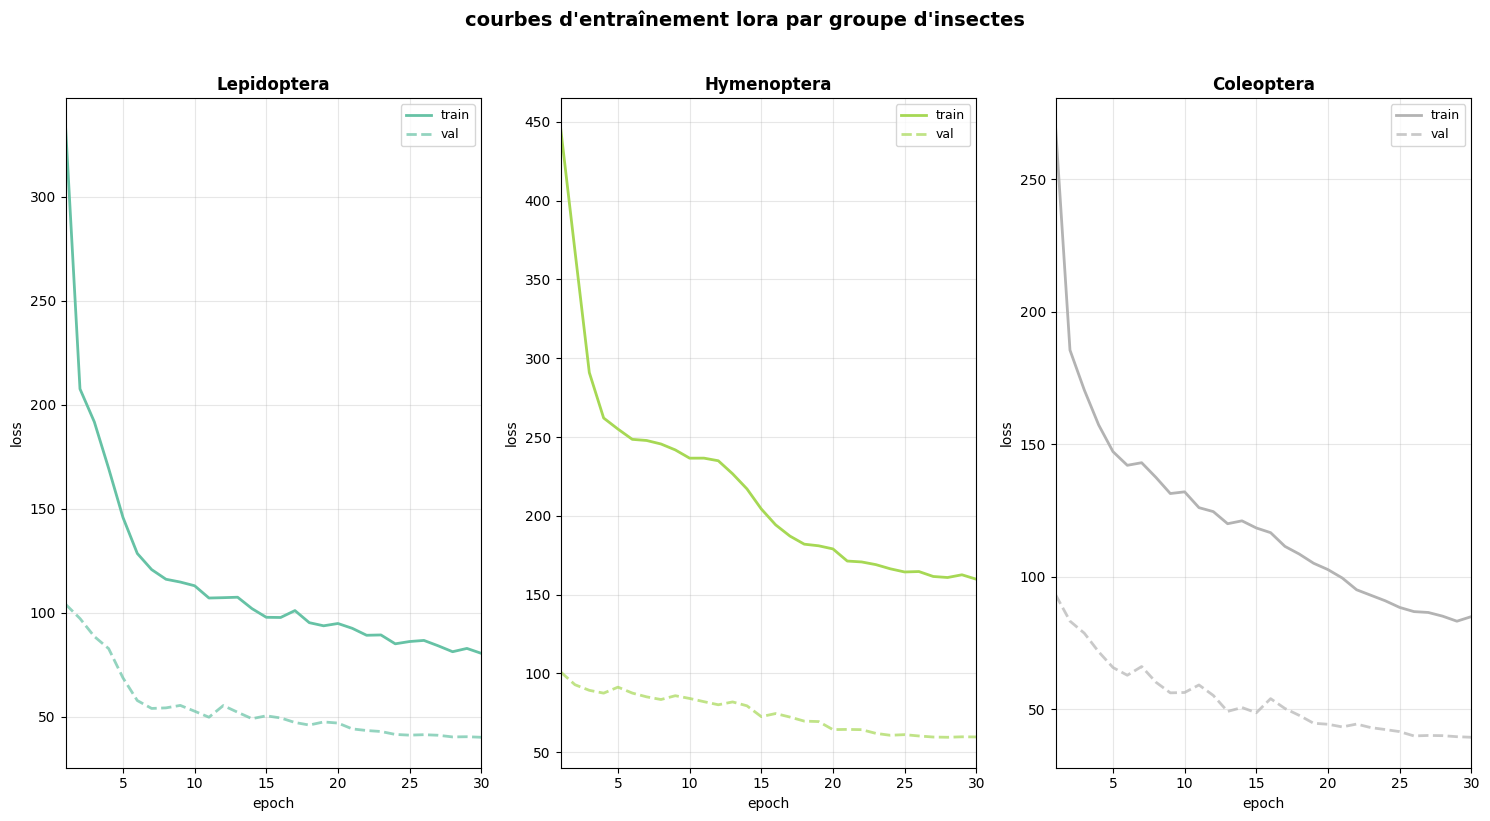

In [ ]:
def plot_training_curves(
    histories: Dict[str, Dict[str, List[float]]],
    figsize: Tuple[int, int] = (15, 8),
):
    """affiche les courbes de loss train/val pour chaque groupe."""
    groups = [g for g, h in histories.items() if not all(math.isnan(v) for v in h["train"])]
    if not groups:
        print("pas de données réelles (dry_run) — affichage simulé.")
        np.random.seed(42)
        groups = list(histories.keys())
        for g in groups:
            n = train_cfg.epochs
            histories[g]["train"] = (0.5 * np.exp(-np.linspace(0, 3, n)) + 0.05 + 0.01*np.random.randn(n)).tolist()
            histories[g]["val"]   = (0.6 * np.exp(-np.linspace(0, 2.5, n)) + 0.08 + 0.015*np.random.randn(n)).tolist()

    n_groups = len(groups)
    cols = min(3, n_groups)
    rows = math.ceil(n_groups / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    colors = plt.cm.Set2(np.linspace(0, 1, n_groups))

    for i, (group, color) in enumerate(zip(groups, colors)):
        ax = axes[i]
        h  = histories[group]
        epochs = range(1, len(h["train"]) + 1)
        ax.plot(epochs, h["train"], color=color, lw=2, label="train")
        ax.plot(epochs, h["val"],   color=color, lw=2, ls="--", label="val", alpha=0.7)
        ax.set_title(group.capitalize(), fontsize=12, fontweight="bold")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, len(h["train"]))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("courbes d'entraînement lora par groupe d'insectes",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


plot_training_curves(all_histories)


## 9. Analyse de la compression LoRA

Comparaison du coût de stockage : full fine-tuning vs LoRA.


────────────────────────────────────────────────────────────
  paramètres backbone (gelés)   :      7,532,002
  paramètres lora par groupe    :        628,288
  ratio de compression          :           12.0×
  mémoire backbone (mo)         :          30.13
  mémoire lora / groupe (mo)    :         2.5132
────────────────────────────────────────────────────────────
  stockage 3 groupes — full ft  :      90.38 mo
  stockage 3 groupes — lora     :      37.67 mo
  économie totale               : 2.4×
────────────────────────────────────────────────────────────


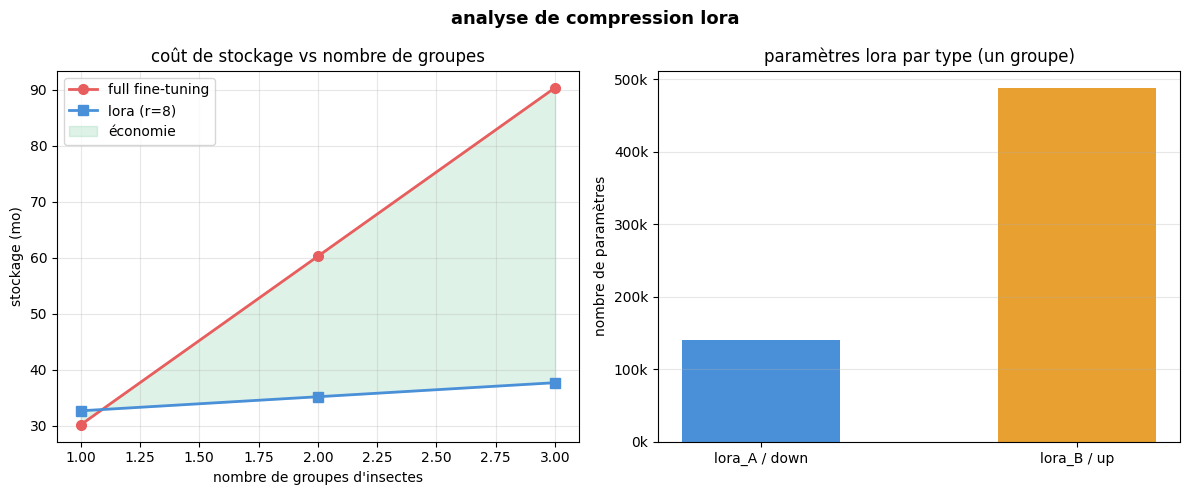

In [ ]:
def analyse_compression(
    model: YOLOPoseLoRA,
    lora_config: LoRAConfig,
    n_groups: int = 5,
):
    """tableau et graphe comparatif full fine-tuning vs lora."""
    stats = count_parameters(model.backbone)
    total = stats["total"]
    lora_n = stats["trainable"]

    bytes_per_param    = 4
    full_mb_per_group  = total  * bytes_per_param / 1e6
    lora_mb_per_group  = lora_n * bytes_per_param / 1e6
    base_mb            = total  * bytes_per_param / 1e6

    print("\n" + "─" * 60)
    print(f"  paramètres backbone (gelés)   : {total:>14,}")
    print(f"  paramètres lora par groupe    : {lora_n:>14,}")
    print(f"  ratio de compression          : {total/lora_n:>14.1f}×")
    print(f"  mémoire backbone (mo)         : {base_mb:>14.2f}")
    print(f"  mémoire lora / groupe (mo)    : {lora_mb_per_group:>14.4f}")
    print("─" * 60)
    print(f"  stockage {n_groups} groupes — full ft  : {n_groups * full_mb_per_group:>10.2f} mo")
    print(f"  stockage {n_groups} groupes — lora     : {base_mb + n_groups * lora_mb_per_group:>10.2f} mo")
    print(f"  économie totale               : {(n_groups*full_mb_per_group) / (base_mb + n_groups*lora_mb_per_group):.1f}×")
    print("─" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    group_counts = range(1, n_groups + 1)
    full_storage = [g * full_mb_per_group for g in group_counts]
    lora_storage = [base_mb + g * lora_mb_per_group for g in group_counts]

    axes[0].plot(group_counts, full_storage, "o-", color="#E85D5D", lw=2, ms=7, label="full fine-tuning")
    axes[0].plot(group_counts, lora_storage, "s-", color="#4A90D9", lw=2, ms=7, label=f"lora (r={lora_config.rank})")
    axes[0].fill_between(group_counts, lora_storage, full_storage, alpha=0.15, color="#27AE60", label="économie")
    axes[0].set_xlabel("nombre de groupes d'insectes")
    axes[0].set_ylabel("stockage (mo)")
    axes[0].set_title("coût de stockage vs nombre de groupes")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    lora_state = LoRAWeightManager.extract_lora_state(model.backbone)
    if lora_state:
        type_counts = {"lora_A / down": 0, "lora_B / up": 0}
        for k, v in lora_state.items():
            if "lora_A" in k or "lora_down" in k:
                type_counts["lora_A / down"] += v.numel()
            else:
                type_counts["lora_B / up"] += v.numel()
        axes[1].bar(type_counts.keys(), type_counts.values(),
                    color=["#4A90D9", "#E8A030"], width=0.5)
        axes[1].set_ylabel("nombre de paramètres")
        axes[1].set_title("paramètres lora par type (un groupe)")
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
        axes[1].grid(True, axis="y", alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "lora non chargé", ha="center", va="center",
                     transform=axes[1].transAxes)

    plt.suptitle("analyse de compression lora", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


analyse_compression(model, lora_cfg, n_groups=len(insect_cfg.groups))


## 10. Inférence avec sélection du groupe

Point d'entrée à brancher avec le classifieur de groupe (implémentation future).

In [ ]:
class InsectPosePredictor:
    """
    pipeline d'inférence complet.

    utilisation avec classifieur futur :
        predictor = InsectPosePredictor(model, lora_manager)
        group = classifier.predict(image)          # à implémenter
        results = predictor.predict(image, group=group)
    """

    def __init__(
        self,
        model: YOLOPoseLoRA,
        manager: LoRAWeightManager,
        img_size: int = 640,
    ):
        self.model    = model
        self.manager  = manager
        self.img_size = img_size
        self._transform = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def predict(
        self,
        image: np.ndarray,
        group: str,
        conf_threshold: float = 0.25,
    ) -> Dict:
        """
        args:
            image : np.ndarray rgb (h, w, 3)
            group : nom du groupe fourni par le classifieur
        returns:
            dict avec 'boxes', 'keypoints', 'scores'
        """
        if self.model.active_group != group:
            self.model.switch_group(group, self.manager)

        h_orig, w_orig = image.shape[:2]
        img_resized = cv2.resize(image, (self.img_size, self.img_size))
        tensor = self._transform(img_resized).unsqueeze(0).to(DEVICE)

        self.model.backbone.eval()
        with torch.no_grad():
            raw_preds = self.model(tensor)

        return self._decode_predictions(raw_preds, (h_orig, w_orig), conf_threshold)

    def _decode_predictions(self, raw, orig_shape, conf_thr):
        """placeholder — remplacer par le décodeur ultralytics."""
        boxes, keypoints, scores = [], [], []

        if raw.boxes is not None:
            for box, score in zip(raw.boxes.xyxy.cpu(), raw.boxes.conf.cpu()):
                boxes.append(box.tolist())
                scores.append(score.item())

        if raw.keypoints is not None:
            for kps in raw.keypoints.data.cpu():
                keypoints.append(kps.tolist())

        return {
            "boxes":     boxes,
            "keypoints": keypoints,
            "scores":    scores,
            "group":     self.model.active_group,
        }

    @staticmethod
    def visualize(
        image: np.ndarray,
        results: Dict,
        skeleton: Optional[List[Tuple[int, int]]] = None,
    ):
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(image)
        colors_kp = plt.cm.plasma(np.linspace(0, 1, 42))

        for box, kps, score in zip(results["boxes"], results["keypoints"], results["scores"]):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      lw=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"{score:.2f}", color='lime', fontsize=9)

            for j, (kx, ky, kv) in enumerate(kps):
                if kv > 0:
                    ax.scatter(kx, ky, c=[colors_kp[j % len(colors_kp)]], s=30, zorder=5)

            if skeleton:
                for i, j in skeleton:
                    if i < len(kps) and j < len(kps) and kps[i][2] > 0 and kps[j][2] > 0:
                        ax.plot([kps[i][0], kps[j][0]], [kps[i][1], kps[j][1]],
                                color='cyan', lw=1.5, alpha=0.8)

        ax.set_title(f"groupe : {results.get('group', 'N/A')} — {len(results['boxes'])} insecte(s)",
                     fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()


predictor = InsectPosePredictor(model, lora_manager)
print("✓ InsectPosePredictor prêt")

dummy_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
# results = predictor.predict(dummy_image, group="coleoptera")
# predictor.visualize(dummy_image, results)
print("(inférence commentée — décommenter avec vos données réelles)")


✓ InsectPosePredictor prêt
(inférence commentée — décommenter avec vos données réelles)


## 11. Analyse du rang optimal

Le rang `r` est le principal hyperparamètre LoRA. On évalue la qualité de la reconstruction pour différents rangs.


analyse svd sur 91 matrices...



  rang  erreur moy.    params lora  compression
--------------------------------------------------
  r=2         0.8870        100,646        74.8×
  r=4         0.8319        201,292        37.4×
  r=8         0.7669        402,675        18.7×
  r=16        0.6723        805,441         9.4×
  r=32        0.5196      1,610,973         4.7×
  r=64        0.2864      3,221,946         2.3×


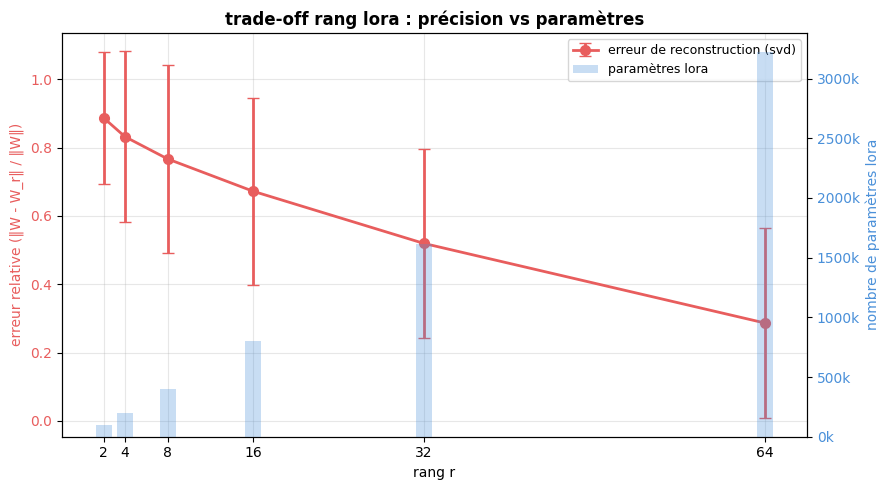

In [ ]:
def analyse_rank_sensitivity(
    model: YOLOPoseLoRA,
    ranks: List[int] = [2, 4, 8, 16, 32, 64],
):
    """
    mesure pour chaque rang r : nombre de paramètres lora et erreur
    de reconstruction par décomposition svd sur les couches du backbone.
    """
    stats_total = count_parameters(model.backbone)
    total_base  = stats_total["total"]

    weight_matrices = []
    for name, module in model.backbone.named_modules():
        if isinstance(module, LoRAConv2d):
            W    = module.base_layer.weight.detach()
            W_2d = W.view(W.shape[0], -1)
            if min(W_2d.shape) >= max(ranks):
                weight_matrices.append((name, W_2d))
        elif isinstance(module, LoRALinear):
            W = module.base_layer.weight.detach()
            if min(W.shape) >= max(ranks):
                weight_matrices.append((name, W))

    if not weight_matrices:
        print("aucune matrice compatible — simulation.")
        weight_matrices = [(f"layer_{i}", torch.randn(256, 128)) for i in range(5)]

    print(f"\nanalyse svd sur {len(weight_matrices)} matrices...")

    results = {}
    for r in ranks:
        errors, param_counts = [], []
        for name, W in weight_matrices:
            try:
                U, S, Vt = torch.linalg.svd(W, full_matrices=False)
                W_approx  = (U[:, :r] * S[:r]) @ Vt[:r, :]
                errors.append(((W - W_approx).norm() / W.norm()).item())
                param_counts.append(r * (W.shape[0] + W.shape[1]))
            except Exception:
                pass

        if errors:
            results[r] = {
                "mean_error":  np.mean(errors),
                "std_error":   np.std(errors),
                "lora_params": int(np.mean(param_counts)) * len(weight_matrices),
                "compression": total_base / max(int(np.mean(param_counts)) * len(weight_matrices), 1),
            }

    print(f"\n{'rang':>6} {'erreur moy.':>12} {'params lora':>14} {'compression':>12}")
    print("-" * 50)
    for r, s in results.items():
        print(f"  r={r:<4} {s['mean_error']:>11.4f} {s['lora_params']:>14,} {s['compression']:>11.1f}×")

    fig, ax1 = plt.subplots(figsize=(9, 5))
    r_vals = list(results.keys())
    errors = [results[r]["mean_error"]  for r in r_vals]
    stds   = [results[r]["std_error"]   for r in r_vals]
    params = [results[r]["lora_params"] for r in r_vals]

    ax1.errorbar(r_vals, errors, yerr=stds, fmt="o-", color="#E85D5D",
                 lw=2, ms=7, capsize=4, label="erreur de reconstruction (svd)")
    ax1.set_xlabel("rang r")
    ax1.set_ylabel("erreur relative (‖W - W_r‖ / ‖W‖)", color="#E85D5D")
    ax1.tick_params(axis="y", labelcolor="#E85D5D")
    ax1.set_xticks(r_vals)

    ax2 = ax1.twinx()
    ax2.bar(r_vals, params, alpha=0.3, color="#4A90D9", width=1.5, label="paramètres lora")
    ax2.set_ylabel("nombre de paramètres lora", color="#4A90D9")
    ax2.tick_params(axis="y", labelcolor="#4A90D9")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
    ax1.set_title("trade-off rang lora : précision vs paramètres", fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results


rank_analysis = analyse_rank_sensitivity(model)


## 12. Résumé final & roadmap

Ce notebook implémente le pipeline complet suivant :

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          résumé du pipeline yolo-pose + lora                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ① backbone         yolov8-pose  (poids figés)                  ║
║                      └─ feature extractor partagé               ║
║                                                                  ║
║  ② lora adapters    ΔW = (α/r) · B·A                           ║
║                      └─ r ≪ d  → paramètres réduits            ║
║                      └─ B=0 à l'init → démarrage stable        ║
║                                                                  ║
║  ③ groupes          un jeu (A,B) par famille d'insectes         ║
║                      coléoptères / hyménoptères / ...           ║
║                                                                  ║
║  ④ stockage         ~0.01 mo par groupe (vs ~30 mo full ft)     ║
║                                                                  ║
║  ⑤ inférence        switch_group(name) → 1 seul modèle gpu     ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  roadmap                                                         ║
║  □  intégrer le décodeur ultralytics (loss + nms)               ║
║  □  ajouter le classifieur de groupe (vision transformer léger) ║
║  □  évaluer oks (object keypoint similarity) par groupe         ║
║  □  tester lora sur les têtes de détection uniquement           ║
║  □  quantification int8 des poids de base                       ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║          résumé du pipeline yolo-pose + lora                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ① backbone         yolov8-pose  (poids figés)                  ║
║                      └─ feature extractor partagé               ║
║                                                                  ║
║  ② lora adapters    ΔW = (α/r) · B·A                           ║
║                      └─ r ≪ d  → paramètres réduits            ║
║                      └─ B=0 à l'init → démarrage stable        ║
║                                                                  ║
║  ③ groupes          un jeu (A,B) par famille d'insectes         ║
║                      coléoptères / hyménoptères / ...           ║
║                                                                  ║
║  ④ stockage         ~0.01 mo par groupe (v